# 07 - Dimension Scaling Sweep

This notebook extends the basket-size experiment beyond `N=5`.

The goal is not to build a new structural model. It is to test whether the correlation-model-risk effect survives as the basket grows:

- `N = 2, 3, 4, 5, 6, 8, 10`,
- equal-weight baskets,
- monthly delta hedging only,
- the same harsh regime environment as notebook 05.

Because this is a wider scaling sweep, the Monte Carlo settings are slightly lighter than the earlier high-precision notebooks. The point here is trend detection across `N`, together with explicit runtime tracking.

In [1]:
from pathlib import Path
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

plt.style.use("seaborn-v0_8-whitegrid")
np.set_printoptions(precision=4, suppress=True)

In [2]:
base_dir = Path.cwd()
repo_root = base_dir.parent if base_dir.name == "notebooks" else base_dir
data_dir = repo_root / "data" / "synthetic"

asset_names_full = [f"Asset_{idx}" for idx in range(1, 11)]
spot_full = np.array([100.0, 95.0, 110.0, 105.0, 90.0, 115.0, 98.0, 108.0, 92.0, 102.0])
vol_full = np.array([0.20, 0.25, 0.22, 0.18, 0.24, 0.21, 0.19, 0.23, 0.26, 0.17])
div_yield_full = np.zeros_like(spot_full)

rate = 0.03
maturity = 1.0
trading_days = 252
start_regime = 0

rho_constant_level = 0.35
rho_calm_level = 0.20
rho_stress_level = 0.98
stress_share_target = 0.40
lambda_daily = 0.08

n_assets_grid = [2, 3, 4, 5, 6, 8, 10]
hedge_steps = 12

# Lighter settings than notebooks 05 and 06 because this is a broader sweep.
n_true_world_paths = 80
delta_mc_paths = 800
initial_price_mc_paths = 8000
repeat_count = 4
bump_fraction = 0.01

asset_table = pd.DataFrame(
    {
        "asset_name": asset_names_full,
        "spot": spot_full,
        "volatility": vol_full,
        "dividend_yield": div_yield_full,
    }
)

config = pd.Series(
    {
        "rho_constant": rho_constant_level,
        "rho_calm": rho_calm_level,
        "rho_stress": rho_stress_level,
        "stress_share_target": stress_share_target,
        "lambda_daily": lambda_daily,
        "hedge_steps": hedge_steps,
        "true_world_paths": n_true_world_paths,
        "delta_mc_paths": delta_mc_paths,
        "initial_price_mc_paths": initial_price_mc_paths,
        "repeat_count": repeat_count,
        "bump_fraction": bump_fraction,
    },
    name="value",
)

display(asset_table)
display(config.to_frame())

,asset_name,spot,volatility,dividend_yield
0,Asset_1,100.0,0.20,0.0
1,Asset_2,95.0,0.25,0.0
2,Asset_3,110.0,0.22,0.0
3,Asset_4,105.0,0.18,0.0
4,Asset_5,90.0,0.24,0.0
5,Asset_6,115.0,0.21,0.0
6,Asset_7,98.0,0.19,0.0
7,Asset_8,108.0,0.23,0.0
8,Asset_9,92.0,0.26,0.0
9,Asset_10,102.0,0.17,0.0


,value
rho_constant,0.35
rho_calm,0.20
rho_stress,0.98
stress_share_target,0.40
lambda_daily,0.08
hedge_steps,12.00
true_world_paths,80.00
delta_mc_paths,800.00
initial_price_mc_paths,8000.00
repeat_count,4.00


## Shared Helpers

The pricing and hedging machinery is the same one used in notebooks 05 and 06. The only new ingredients are:

- a ten-name synthetic universe,
- monthly-only hedging,
- per-hedger runtime tracking.

In [3]:
def basket_values(prices, weights):
    return prices @ weights


def basket_call_payoff(prices, weights, strike):
    return np.maximum(basket_values(prices, weights) - strike, 0.0)


def maturity_delta(spot, weights, strike):
    basket_level = float(weights @ spot)
    if basket_level > strike:
        return weights.copy()
    if np.isclose(basket_level, strike):
        return 0.5 * weights
    return np.zeros_like(weights)


def equicorrelation_matrix(n_assets, rho):
    corr = np.full((n_assets, n_assets), rho)
    np.fill_diagonal(corr, 1.0)
    return corr


def build_transition_matrix(p01_daily, p10_daily):
    return np.array(
        [
            [1.0 - p01_daily, p01_daily],
            [p10_daily, 1.0 - p10_daily],
        ]
    )


def correlate_draws(base_draws, regime_states, chol_by_regime):
    correlated = np.empty_like(base_draws)
    for regime_value, chol in chol_by_regime.items():
        mask = regime_states == regime_value
        if np.any(mask):
            correlated[mask] = base_draws[mask] @ chol.T
    return correlated


def advance_regimes(current_regimes, transition_matrix, rng):
    prob_to_stress = transition_matrix[current_regimes, 1]
    draws = rng.random(current_regimes.size)
    return (draws < prob_to_stress).astype(np.int8)


def simulate_regime_true_world_paths(
    spot,
    rate,
    div_yield,
    vol,
    chol_calm,
    chol_stress,
    maturity,
    hedge_steps,
    n_paths,
    transition_hedge,
    start_regime,
    rng,
):
    n_assets = spot.size
    dt = maturity / hedge_steps
    drift = (rate - div_yield - 0.5 * vol ** 2) * dt
    diffusion = vol * np.sqrt(dt)
    chol_by_regime = {0: chol_calm, 1: chol_stress}

    paths = np.empty((n_paths, hedge_steps + 1, n_assets))
    regimes = np.empty((n_paths, hedge_steps), dtype=np.int8)
    paths[:, 0, :] = spot
    current_regimes = np.full(n_paths, start_regime, dtype=np.int8)

    for step in range(hedge_steps):
        regimes[:, step] = current_regimes
        base_draws = rng.standard_normal((n_paths, n_assets))
        correlated_draws = correlate_draws(base_draws, current_regimes, chol_by_regime)
        log_increment = drift + diffusion * correlated_draws
        paths[:, step + 1, :] = paths[:, step, :] * np.exp(log_increment)

        if step < hedge_steps - 1:
            current_regimes = advance_regimes(current_regimes, transition_hedge, rng)

    return paths, regimes


def constant_model_terminal_factors(spot, rate, div_yield, vol, tau, chol_constant, n_samples, rng):
    if tau <= 0.0:
        return np.ones((n_samples, spot.size))
    drift = (rate - div_yield - 0.5 * vol ** 2) * tau
    diffusion = vol * np.sqrt(tau)
    shocks = rng.standard_normal((n_samples, spot.size)) @ chol_constant.T
    return np.exp(drift + diffusion * shocks)


def regime_model_terminal_factors(
    spot,
    rate,
    div_yield,
    vol,
    hedge_dt,
    steps_remaining,
    chol_calm,
    chol_stress,
    transition_hedge,
    start_regime,
    n_samples,
    rng,
):
    if steps_remaining <= 0:
        return np.ones((n_samples, spot.size))

    drift = (rate - div_yield - 0.5 * vol ** 2) * hedge_dt
    diffusion = vol * np.sqrt(hedge_dt)
    chol_by_regime = {0: chol_calm, 1: chol_stress}
    current_regimes = np.full(n_samples, start_regime, dtype=np.int8)
    log_factors = np.zeros((n_samples, spot.size))

    for step in range(steps_remaining):
        base_draws = rng.standard_normal((n_samples, spot.size))
        correlated_draws = correlate_draws(base_draws, current_regimes, chol_by_regime)
        log_factors += drift + diffusion * correlated_draws
        if step < steps_remaining - 1:
            current_regimes = advance_regimes(current_regimes, transition_hedge, rng)

    return np.exp(log_factors)

In [4]:
def price_and_delta_from_terminal_factors(spot, terminal_factors, weights, strike, rate, tau, bump_fraction):
    terminal_prices = terminal_factors * spot
    discount = np.exp(-rate * tau)
    price = discount * basket_call_payoff(terminal_prices, weights, strike).mean()

    bump_sizes = bump_fraction * np.maximum(spot, 1.0)
    deltas = np.empty_like(spot)
    for asset_idx in range(spot.size):
        up_spot = spot[asset_idx] + bump_sizes[asset_idx]
        down_spot = max(spot[asset_idx] - bump_sizes[asset_idx], 1e-8)
        denominator = up_spot - down_spot

        up_terminal = terminal_prices.copy()
        down_terminal = terminal_prices.copy()
        up_terminal[:, asset_idx] = terminal_factors[:, asset_idx] * up_spot
        down_terminal[:, asset_idx] = terminal_factors[:, asset_idx] * down_spot

        up_payoff = basket_call_payoff(up_terminal, weights, strike)
        down_payoff = basket_call_payoff(down_terminal, weights, strike)
        deltas[asset_idx] = discount * (up_payoff.mean() - down_payoff.mean()) / denominator

    return price, deltas


def constant_model_price_and_delta(spot, tau, weights, strike, rate, div_yield, vol, chol_constant, n_samples, bump_fraction, rng):
    if tau <= 0.0:
        payoff = float(basket_call_payoff(spot[None, :], weights, strike)[0])
        return payoff, maturity_delta(spot, weights, strike)
    terminal_factors = constant_model_terminal_factors(spot, rate, div_yield, vol, tau, chol_constant, n_samples, rng)
    return price_and_delta_from_terminal_factors(spot, terminal_factors, weights, strike, rate, tau, bump_fraction)


def regime_model_price_and_delta(
    spot,
    steps_remaining,
    current_regime,
    weights,
    strike,
    rate,
    div_yield,
    vol,
    hedge_dt,
    chol_calm,
    chol_stress,
    transition_hedge,
    n_samples,
    bump_fraction,
    rng,
):
    tau = steps_remaining * hedge_dt
    if steps_remaining <= 0:
        payoff = float(basket_call_payoff(spot[None, :], weights, strike)[0])
        return payoff, maturity_delta(spot, weights, strike)
    terminal_factors = regime_model_terminal_factors(
        spot,
        rate,
        div_yield,
        vol,
        hedge_dt,
        steps_remaining,
        chol_calm,
        chol_stress,
        transition_hedge,
        current_regime,
        n_samples,
        rng,
    )
    return price_and_delta_from_terminal_factors(spot, terminal_factors, weights, strike, rate, tau, bump_fraction)


def pnl_summary(pnl):
    return {
        "mean_pnl": float(np.mean(pnl)),
        "std_pnl": float(np.std(pnl, ddof=1)),
        "q05_pnl": float(np.quantile(pnl, 0.05)),
        "q01_pnl": float(np.quantile(pnl, 0.01)),
    }


def evaluate_hedger(true_paths, true_regimes, hedge_model, pricing_inputs, base_seed):
    time_start = time.perf_counter()

    if hedge_model == "constant":
        initial_price, initial_delta = constant_model_price_and_delta(
            spot=pricing_inputs["spot"],
            tau=pricing_inputs["maturity"],
            weights=pricing_inputs["weights"],
            strike=pricing_inputs["strike"],
            rate=pricing_inputs["rate"],
            div_yield=pricing_inputs["div_yield"],
            vol=pricing_inputs["vol"],
            chol_constant=pricing_inputs["chol_constant"],
            n_samples=pricing_inputs["initial_price_mc_paths"],
            bump_fraction=pricing_inputs["bump_fraction"],
            rng=np.random.default_rng(base_seed + 1),
        )
    else:
        initial_price, initial_delta = regime_model_price_and_delta(
            spot=pricing_inputs["spot"],
            steps_remaining=pricing_inputs["hedge_steps"],
            current_regime=pricing_inputs["start_regime"],
            weights=pricing_inputs["weights"],
            strike=pricing_inputs["strike"],
            rate=pricing_inputs["rate"],
            div_yield=pricing_inputs["div_yield"],
            vol=pricing_inputs["vol"],
            hedge_dt=pricing_inputs["hedge_dt"],
            chol_calm=pricing_inputs["chol_calm"],
            chol_stress=pricing_inputs["chol_stress"],
            transition_hedge=pricing_inputs["transition_hedge"],
            n_samples=pricing_inputs["initial_price_mc_paths"],
            bump_fraction=pricing_inputs["bump_fraction"],
            rng=np.random.default_rng(base_seed + 2),
        )

    terminal_payoff = basket_call_payoff(true_paths[:, -1, :], pricing_inputs["weights"], pricing_inputs["strike"])
    n_paths = true_paths.shape[0]
    cash_account = np.full(n_paths, initial_price) - true_paths[:, 0, :] @ initial_delta
    delta_holdings = np.tile(initial_delta, (n_paths, 1))

    for step in range(pricing_inputs["hedge_steps"] - 1):
        next_spots = true_paths[:, step + 1, :]
        cash_account *= np.exp(pricing_inputs["rate"] * pricing_inputs["hedge_dt"])
        portfolio_before = cash_account + np.sum(delta_holdings * next_spots, axis=1)
        remaining_steps = pricing_inputs["hedge_steps"] - (step + 1)
        new_deltas = np.empty_like(delta_holdings)

        for path_idx in range(n_paths):
            state_rng = np.random.default_rng(base_seed + 10000 * (step + 1) + path_idx)
            if hedge_model == "constant":
                _, state_delta = constant_model_price_and_delta(
                    spot=next_spots[path_idx],
                    tau=remaining_steps * pricing_inputs["hedge_dt"],
                    weights=pricing_inputs["weights"],
                    strike=pricing_inputs["strike"],
                    rate=pricing_inputs["rate"],
                    div_yield=pricing_inputs["div_yield"],
                    vol=pricing_inputs["vol"],
                    chol_constant=pricing_inputs["chol_constant"],
                    n_samples=pricing_inputs["delta_mc_paths"],
                    bump_fraction=pricing_inputs["bump_fraction"],
                    rng=state_rng,
                )
            else:
                _, state_delta = regime_model_price_and_delta(
                    spot=next_spots[path_idx],
                    steps_remaining=remaining_steps,
                    current_regime=int(true_regimes[path_idx, step + 1]),
                    weights=pricing_inputs["weights"],
                    strike=pricing_inputs["strike"],
                    rate=pricing_inputs["rate"],
                    div_yield=pricing_inputs["div_yield"],
                    vol=pricing_inputs["vol"],
                    hedge_dt=pricing_inputs["hedge_dt"],
                    chol_calm=pricing_inputs["chol_calm"],
                    chol_stress=pricing_inputs["chol_stress"],
                    transition_hedge=pricing_inputs["transition_hedge"],
                    n_samples=pricing_inputs["delta_mc_paths"],
                    bump_fraction=pricing_inputs["bump_fraction"],
                    rng=state_rng,
                )
            new_deltas[path_idx] = state_delta

        cash_account = portfolio_before - np.sum(new_deltas * next_spots, axis=1)
        delta_holdings = new_deltas

    cash_account *= np.exp(pricing_inputs["rate"] * pricing_inputs["hedge_dt"])
    pnl = cash_account + np.sum(delta_holdings * true_paths[:, -1, :], axis=1) - terminal_payoff

    return {
        "runtime_seconds": float(time.perf_counter() - time_start),
        "initial_price": initial_price,
        **pnl_summary(pnl),
    }

In [5]:
def run_dimension_scenario(n_assets, repeat_id, scenario_seed):
    spot = spot_full[:n_assets].copy()
    vol = vol_full[:n_assets].copy()
    div_yield = div_yield_full[:n_assets].copy()
    weights = np.full(n_assets, 1.0 / n_assets)
    strike = float(weights @ spot)

    p01_daily = stress_share_target * lambda_daily
    p10_daily = (1.0 - stress_share_target) * lambda_daily
    transition_daily = build_transition_matrix(p01_daily, p10_daily)
    transition_hedge = np.linalg.matrix_power(transition_daily, trading_days // hedge_steps)

    chol_constant = np.linalg.cholesky(equicorrelation_matrix(n_assets, rho_constant_level))
    chol_calm = np.linalg.cholesky(equicorrelation_matrix(n_assets, rho_calm_level))
    chol_stress = np.linalg.cholesky(equicorrelation_matrix(n_assets, rho_stress_level))

    pricing_inputs = {
        "spot": spot,
        "weights": weights,
        "strike": strike,
        "rate": rate,
        "div_yield": div_yield,
        "vol": vol,
        "maturity": maturity,
        "hedge_steps": hedge_steps,
        "hedge_dt": maturity / hedge_steps,
        "delta_mc_paths": delta_mc_paths,
        "initial_price_mc_paths": initial_price_mc_paths,
        "bump_fraction": bump_fraction,
        "chol_constant": chol_constant,
        "chol_calm": chol_calm,
        "chol_stress": chol_stress,
        "transition_hedge": transition_hedge,
        "start_regime": start_regime,
    }

    true_paths, true_regimes = simulate_regime_true_world_paths(
        spot=spot,
        rate=rate,
        div_yield=div_yield,
        vol=vol,
        chol_calm=chol_calm,
        chol_stress=chol_stress,
        maturity=maturity,
        hedge_steps=hedge_steps,
        n_paths=n_true_world_paths,
        transition_hedge=transition_hedge,
        start_regime=start_regime,
        rng=np.random.default_rng(scenario_seed),
    )

    rows = []
    for hedger_idx, hedger in enumerate(["constant", "regime"]):
        summary = evaluate_hedger(
            true_paths=true_paths,
            true_regimes=true_regimes,
            hedge_model=hedger,
            pricing_inputs=pricing_inputs,
            base_seed=scenario_seed + 1000 * (hedger_idx + 1),
        )
        rows.append(
            {
                "n_assets": n_assets,
                "repeat_id": repeat_id,
                "strike": strike,
                "avg_stress_fraction": float(true_regimes.mean()),
                "hedger": hedger,
                **summary,
            }
        )

    return pd.DataFrame(rows)


raw_rows = []
for n_idx, n_assets in enumerate(n_assets_grid, start=1):
    for repeat_id in range(repeat_count):
        scenario_seed = 91000 + 7000 * n_idx + 200 * repeat_id
        raw_rows.append(run_dimension_scenario(n_assets, repeat_id, scenario_seed))

scaling_raw = pd.concat(raw_rows, ignore_index=True)

scaling_summary = (
    scaling_raw.groupby(["n_assets", "hedger"], as_index=False)
    .agg(
        avg_initial_price=("initial_price", "mean"),
        avg_mean_pnl=("mean_pnl", "mean"),
        avg_std_pnl=("std_pnl", "mean"),
        std_of_std_pnl=("std_pnl", "std"),
        avg_q05_pnl=("q05_pnl", "mean"),
        avg_q01_pnl=("q01_pnl", "mean"),
        std_of_q01_pnl=("q01_pnl", "std"),
        avg_runtime_seconds=("runtime_seconds", "mean"),
        avg_stress_fraction=("avg_stress_fraction", "mean"),
    )
)

scaling_gap = scaling_summary.pivot(
    index="n_assets",
    columns="hedger",
    values=["avg_initial_price", "avg_std_pnl", "avg_q05_pnl", "avg_q01_pnl", "avg_mean_pnl", "avg_runtime_seconds"],
)
scaling_gap.columns = ["_".join(col).strip() for col in scaling_gap.columns.to_flat_index()]
scaling_gap = scaling_gap.reset_index()
scaling_gap["price_gap_constant_minus_regime"] = scaling_gap["avg_initial_price_constant"] - scaling_gap["avg_initial_price_regime"]
scaling_gap["std_gap_constant_minus_regime"] = scaling_gap["avg_std_pnl_constant"] - scaling_gap["avg_std_pnl_regime"]
scaling_gap["q05_gap_regime_minus_constant"] = scaling_gap["avg_q05_pnl_regime"] - scaling_gap["avg_q05_pnl_constant"]
scaling_gap["q01_gap_regime_minus_constant"] = scaling_gap["avg_q01_pnl_regime"] - scaling_gap["avg_q01_pnl_constant"]
scaling_gap["mean_gap_regime_minus_constant"] = scaling_gap["avg_mean_pnl_regime"] - scaling_gap["avg_mean_pnl_constant"]

display(scaling_summary.round(4))
display(scaling_gap.round(4))

,n_assets,hedger,avg_initial_price,avg_mean_pnl,avg_std_pnl,std_of_std_pnl,avg_q05_pnl,avg_q01_pnl,std_of_q01_pnl,avg_runtime_seconds,avg_stress_fraction
0,2,constant,8.7185,-0.1634,1.8557,0.2074,-3.2960,-4.4289,1.2282,0.1526,0.3549
1,2,regime,8.8800,-0.0023,1.8379,0.1507,-3.1446,-4.2157,1.1009,0.5272,0.3549
2,3,constant,8.3756,-0.4997,2.0708,0.1776,-3.8972,-6.0843,0.7129,0.1845,0.3461
3,3,regime,8.7806,-0.0446,2.0302,0.1792,-3.2409,-5.3290,0.5210,0.5585,0.3461
4,4,constant,7.7090,-0.6025,1.6935,0.2155,-3.3166,-5.6278,0.7287,0.2386,0.3503
5,4,regime,8.3559,0.0294,1.6766,0.1679,-2.9161,-4.6650,0.9583,0.6689,0.3503
6,5,constant,7.5470,-0.8735,2.1111,0.2373,-4.7446,-7.1289,1.2612,0.2664,0.3758
7,5,regime,8.1218,-0.2416,2.0067,0.2083,-3.8074,-5.6820,1.2125,0.6545,0.3758
8,6,constant,7.5943,-0.5625,1.9131,0.0881,-3.6357,-6.1749,1.1056,0.4644,0.3529
9,6,regime,8.2750,0.1149,1.8570,0.1182,-2.8894,-4.3647,0.8137,0.9461,0.3529


,n_assets,avg_initial_price_constant,avg_initial_price_regime,avg_std_pnl_constant,avg_std_pnl_regime,avg_q05_pnl_constant,avg_q05_pnl_regime,avg_q01_pnl_constant,avg_q01_pnl_regime,avg_mean_pnl_constant,avg_mean_pnl_regime,avg_runtime_seconds_constant,avg_runtime_seconds_regime,price_gap_constant_minus_regime,std_gap_constant_minus_regime,q05_gap_regime_minus_constant,q01_gap_regime_minus_constant,mean_gap_regime_minus_constant
0,2,8.7185,8.8800,1.8557,1.8379,-3.2960,-3.1446,-4.4289,-4.2157,-0.1634,-0.0023,0.1526,0.5272,-0.1615,0.0178,0.1514,0.2132,0.1612
1,3,8.3756,8.7806,2.0708,2.0302,-3.8972,-3.2409,-6.0843,-5.3290,-0.4997,-0.0446,0.1845,0.5585,-0.4050,0.0406,0.6562,0.7553,0.4552
2,4,7.7090,8.3559,1.6935,1.6766,-3.3166,-2.9161,-5.6278,-4.6650,-0.6025,0.0294,0.2386,0.6689,-0.6469,0.0169,0.4005,0.9628,0.6319
3,5,7.5470,8.1218,2.1111,2.0067,-4.7446,-3.8074,-7.1289,-5.6820,-0.8735,-0.2416,0.2664,0.6545,-0.5747,0.1043,0.9372,1.4469,0.6319
4,6,7.5943,8.2750,1.9131,1.8570,-3.6357,-2.8894,-6.1749,-4.3647,-0.5625,0.1149,0.4644,0.9461,-0.6806,0.0560,0.7463,1.8101,0.6774
5,8,7.2701,8.0018,1.9324,1.8960,-4.0815,-2.8723,-6.7384,-5.2851,-0.7588,0.0301,0.3955,0.8443,-0.7317,0.0363,1.2092,1.4532,0.7889
6,10,7.0809,7.7705,1.8836,1.8968,-3.7656,-3.0041,-6.0545,-4.6671,-0.6313,0.1056,0.4230,1.0430,-0.6895,-0.0132,0.7616,1.3874,0.7368


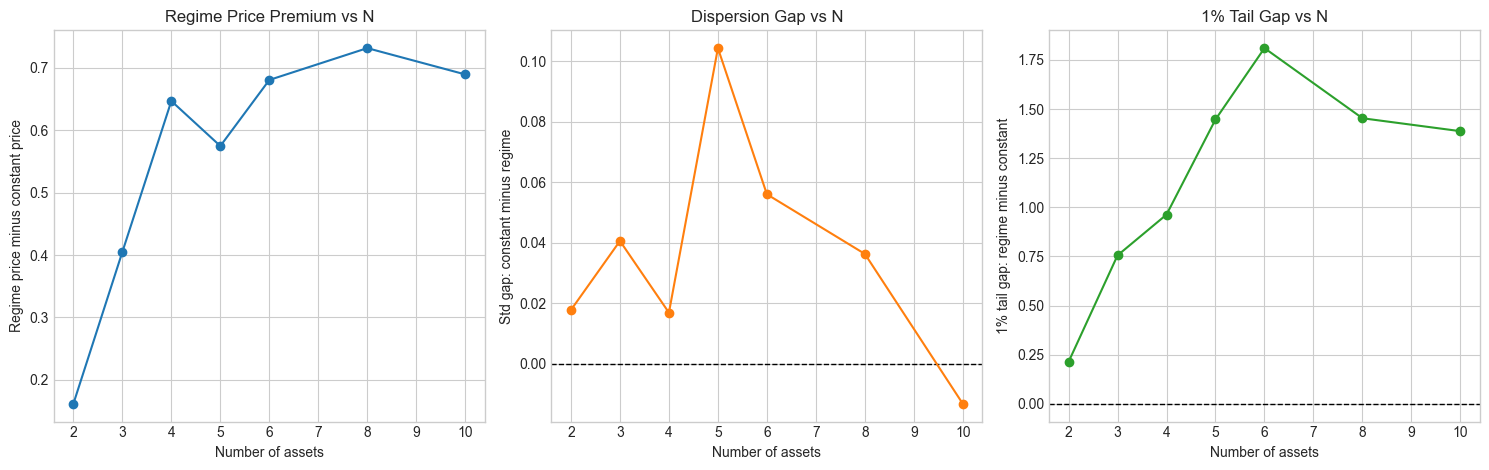

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))

axes[0].plot(scaling_gap["n_assets"], -scaling_gap["price_gap_constant_minus_regime"], marker="o", color="tab:blue")
axes[0].set_title("Regime Price Premium vs N")
axes[0].set_xlabel("Number of assets")
axes[0].set_ylabel("Regime price minus constant price")

axes[1].axhline(0.0, color="black", linestyle="--", linewidth=1.0)
axes[1].plot(scaling_gap["n_assets"], scaling_gap["std_gap_constant_minus_regime"], marker="o", color="tab:orange")
axes[1].set_title("Dispersion Gap vs N")
axes[1].set_xlabel("Number of assets")
axes[1].set_ylabel("Std gap: constant minus regime")

axes[2].axhline(0.0, color="black", linestyle="--", linewidth=1.0)
axes[2].plot(scaling_gap["n_assets"], scaling_gap["q01_gap_regime_minus_constant"], marker="o", color="tab:green")
axes[2].set_title("1% Tail Gap vs N")
axes[2].set_xlabel("Number of assets")
axes[2].set_ylabel("1% tail gap: regime minus constant")

plt.tight_layout()
plt.show()

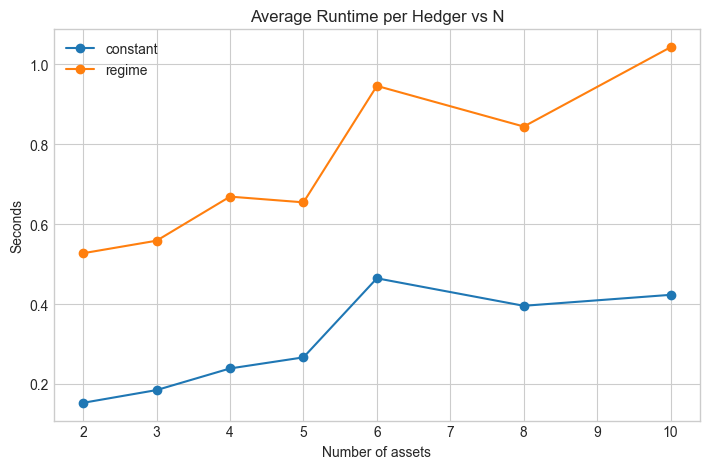

In [7]:
fig, ax = plt.subplots(figsize=(7.2, 4.8))

for hedger, frame in scaling_summary.groupby("hedger"):
    frame = frame.sort_values("n_assets")
    ax.plot(frame["n_assets"], frame["avg_runtime_seconds"], marker="o", label=hedger)

ax.set_title("Average Runtime per Hedger vs N")
ax.set_xlabel("Number of assets")
ax.set_ylabel("Seconds")
ax.legend()

plt.tight_layout()
plt.show()

## Reading the Sweep

Focus on three quantities:

- `regime price minus constant price`: whether the harsher dependence structure raises the option value.
- `std gap = constant minus regime`: whether the regime hedge lowers P&L dispersion.
- `1% tail gap = regime minus constant`: whether the regime hedge improves the left tail.

In this exploratory scaling notebook, the 1% tail gap is the most stable signal. The standard-deviation gap is smaller and can be noisy because the two hedges are already fairly close in overall dispersion.

In [8]:
scaling_raw.to_csv(data_dir / "basket_option_dimension_scaling_raw.csv", index=False)
scaling_summary.to_csv(data_dir / "basket_option_dimension_scaling_summary.csv", index=False)
scaling_gap.to_csv(data_dir / "basket_option_dimension_scaling_gap.csv", index=False)
config.to_csv(data_dir / "basket_option_dimension_scaling_config.csv")

print(f"Saved raw dimension scaling runs to {data_dir / 'basket_option_dimension_scaling_raw.csv'}")
print(f"Saved dimension scaling summary to {data_dir / 'basket_option_dimension_scaling_summary.csv'}")
print(f"Saved dimension scaling gap table to {data_dir / 'basket_option_dimension_scaling_gap.csv'}")
print(f"Saved dimension scaling config to {data_dir / 'basket_option_dimension_scaling_config.csv'}")

Saved raw dimension scaling runs to /Users/hamzaahmed/Multi-Asset Option Pricing/data/synthetic/basket_option_dimension_scaling_raw.csv
Saved dimension scaling summary to /Users/hamzaahmed/Multi-Asset Option Pricing/data/synthetic/basket_option_dimension_scaling_summary.csv
Saved dimension scaling gap table to /Users/hamzaahmed/Multi-Asset Option Pricing/data/synthetic/basket_option_dimension_scaling_gap.csv
Saved dimension scaling config to /Users/hamzaahmed/Multi-Asset Option Pricing/data/synthetic/basket_option_dimension_scaling_config.csv
